# Importing Libraries

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import RandomOverSampler 
import numpy as np
from sklearn.model_selection import train_test_split
import os, cv2
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, Flatten, Dense, MaxPool2D

# Import Data

In [2]:
import pandas as pd
data = pd.read_csv('hmnist_28_28_RGB.csv')
data.head()

,pixel0000,pixel0001,pixel0002,pixel0003,pixel0004,pixel0005,pixel0006,pixel0007,pixel0008,pixel0009,...,pixel2343,pixel2344,pixel2345,pixel2346,pixel2347,pixel2348,pixel2349,pixel2350,pixel2351,label
0,192,153,193,195,155,192,197,154,185,202,...,173,124,138,183,147,166,185,154,177,2
1,25,14,30,68,48,75,123,93,126,158,...,60,39,55,25,14,28,25,14,27,2
2,192,138,153,200,145,163,201,142,160,206,...,167,129,143,159,124,142,136,104,117,2
3,38,19,30,95,59,72,143,103,119,171,...,44,26,36,25,12,17,25,12,15,2
4,158,113,139,194,144,174,215,162,191,225,...,209,166,185,172,135,149,109,78,92,2


In [3]:
y = data['label']
x = data.drop(columns = ['label'])

# Exploratory Data Analysis (EDA)

In [5]:
tabular_data = pd.read_csv('HAM10000_metadata.csv')
tabular_data.head()

,lesion_id,image_id,dx,dx_type,age,sex,localization
0,HAM_0000118,ISIC_0027419,bkl,histo,80.0,male,scalp
1,HAM_0000118,ISIC_0025030,bkl,histo,80.0,male,scalp
2,HAM_0002730,ISIC_0026769,bkl,histo,80.0,male,scalp
3,HAM_0002730,ISIC_0025661,bkl,histo,80.0,male,scalp
4,HAM_0001466,ISIC_0031633,bkl,histo,75.0,male,ear


In [6]:
classes = {4: ('nv', ' melanocytic nevi'), 6: ('mel', 'melanoma'), 2 :('bkl', 'benign keratosis-like lesions'), 1:('bcc' , ' basal cell carcinoma'), 5: ('vasc', ' pyogenic granulomas and hemorrhage'), 0: ('akiec', 'Actinic keratoses and intraepithelial carcinomae'),  3: ('df', 'dermatofibroma')}

# Frequency Distribution of Classes

Text(0.5, 1.0, 'Frequency Distribution of Classes')

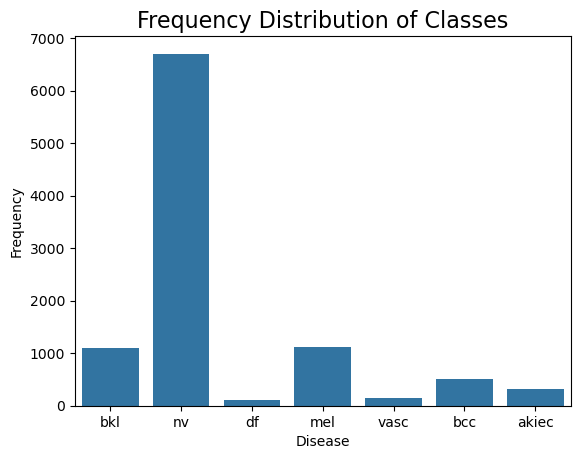

In [13]:
sns.countplot(x = 'dx', data = tabular_data)
plt.xlabel('Disease', size=10)
plt.ylabel('Frequency', size=10)
plt.title('Frequency Distribution of Classes', size=16)

# Distribution of Disease over Gender

Text(0.5, 1.0, 'Gender of Patient')

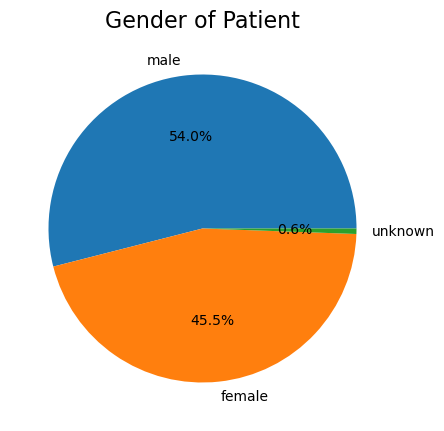

In [14]:
bar, ax = plt.subplots(figsize = (5,5))
plt.pie(tabular_data['sex'].value_counts(), labels = tabular_data['sex'].value_counts().index, autopct="%.1f%%")
plt.title('Gender of Patient', size=16)

# Histogram of Age of Patients

Text(0.5, 1.0, 'Histogram of Age of Patients')

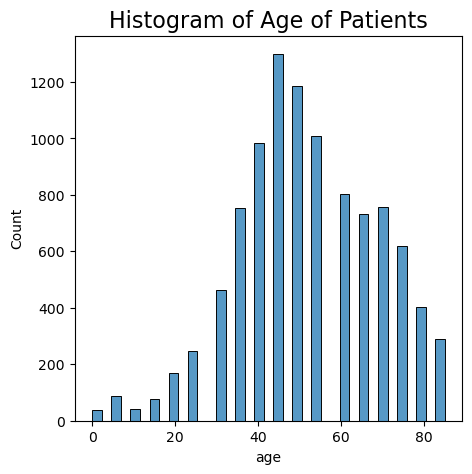

In [16]:
bar, ax = plt.subplots(figsize=(5,5))
sns.histplot(tabular_data['age'])
plt.title('Histogram of Age of Patients', size=16)

# Location of disease over Gender

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14],
 [Text(0, 0, 'back'),
  Text(1, 0, 'lower extremity'),
  Text(2, 0, 'trunk'),
  Text(3, 0, 'upper extremity'),
  Text(4, 0, 'abdomen'),
  Text(5, 0, 'face'),
  Text(6, 0, 'chest'),
  Text(7, 0, 'foot'),
  Text(8, 0, 'scalp'),
  Text(9, 0, 'neck'),
  Text(10, 0, 'unknown'),
  Text(11, 0, 'hand'),
  Text(12, 0, 'genital'),
  Text(13, 0, 'ear'),
  Text(14, 0, 'acral')])

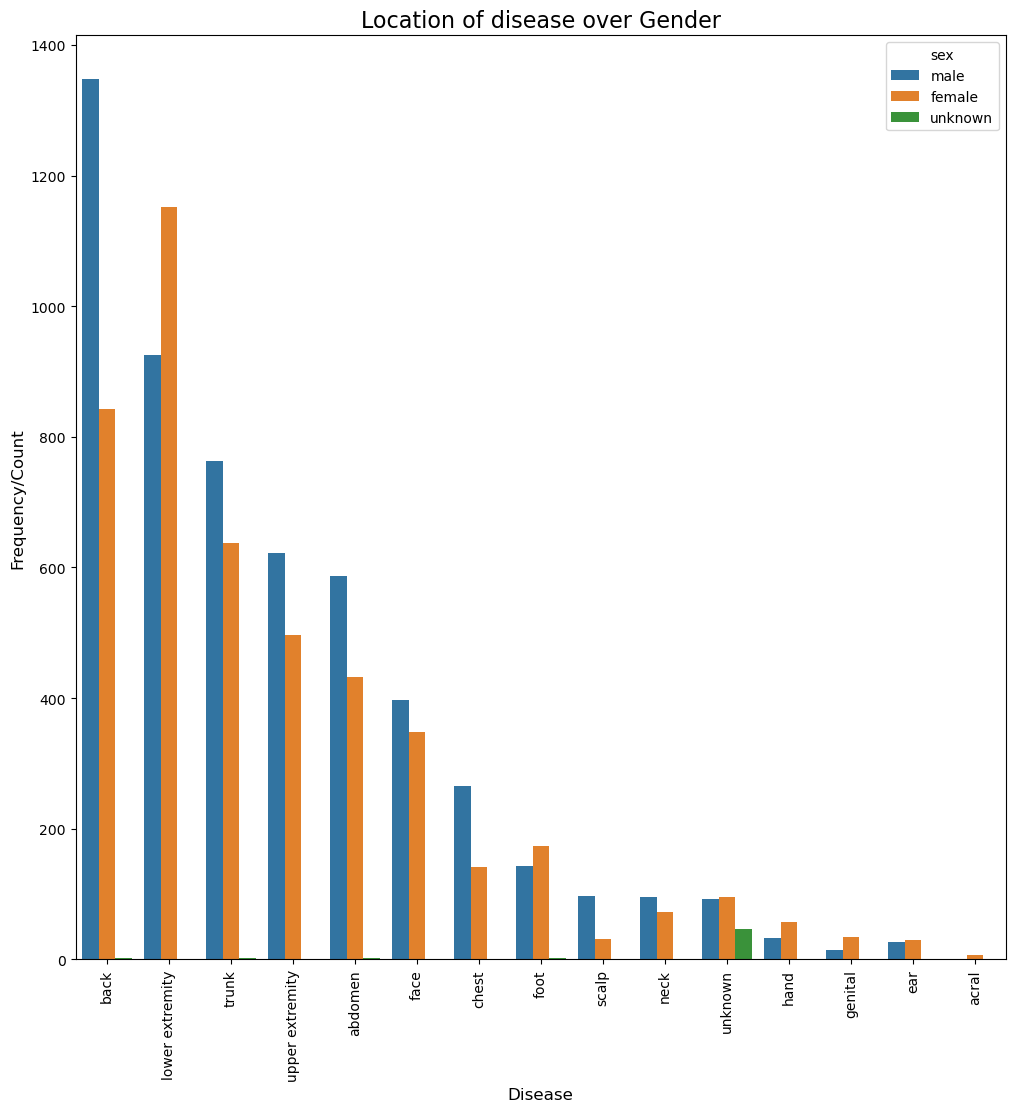

In [17]:
value = tabular_data[['localization', 'sex']].value_counts().to_frame()
value.reset_index(level=[1,0 ], inplace=True)
temp = value.rename(columns = {'localization':'location', 0: 'count'})

bar, ax = plt.subplots(figsize = (12, 12))
sns.barplot(x = 'location',  y='count', hue = 'sex', data = temp)
plt.title('Location of disease over Gender', size = 16)
plt.xlabel('Disease', size=12)
plt.ylabel('Frequency/Count', size=12)
plt.xticks(rotation = 90)

# Oversampling
**To overcome class imbalace**

In [18]:
oversample = RandomOverSampler()
x,y  = oversample.fit_resample(x,y)

In [19]:
x = np.array(x).reshape(-1,28,28,3)
print('Shape of X :',x.shape)

Shape of X : (46935, 28, 28, 3)


C:\Users\Priyanshi\AppData\Local\Temp\ipykernel_25748\1807570631.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=y, palette='viridis')


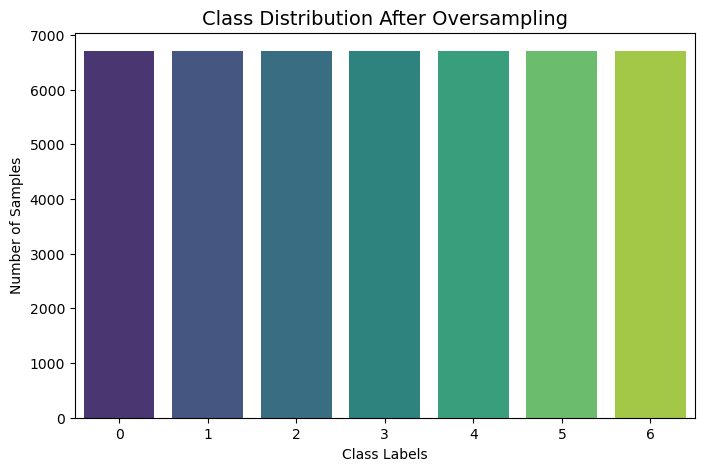

Class distribution after oversampling: Counter({2: 6705, 4: 6705, 3: 6705, 6: 6705, 5: 6705, 1: 6705, 0: 6705})


In [20]:
from collections import Counter
plt.figure(figsize=(8,5))
sns.countplot(x=y, palette='viridis')
plt.title("Class Distribution After Oversampling", fontsize=14)
plt.xlabel("Class Labels")
plt.ylabel("Number of Samples")
plt.show()

# Print numerical distribution
print("Class distribution after oversampling:", Counter(y))

# Standardization and Splitting Data

In [22]:
x = (x-np.mean(x))/np.std(x)
X_train, X_test, Y_train, Y_test = train_test_split(x,y, test_size=0.2, random_state=1)

# Model Training

In [24]:
model = Sequential()
model.add(Conv2D(16, kernel_size = (3,3), input_shape = (28, 28, 3), activation = 'relu', padding = 'same'))
model.add(Conv2D(32, kernel_size = (3,3), activation = 'relu'))
model.add(MaxPool2D(pool_size = (2,2)))
model.add(Conv2D(32, kernel_size = (3,3), activation = 'relu', padding = 'same'))
model.add(Conv2D(64, kernel_size = (3,3), activation = 'relu'))
model.add(MaxPool2D(pool_size = (2,2), padding = 'same'))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(32, activation='relu'))
model.add(Dense(7, activation='softmax'))
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)                    │ (None, 28, 28, 16)          │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 26, 26, 32)          │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 13, 13, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 13, 13, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 11, 11, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 6, 6, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 2304)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 64)                  │         147,520 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 7)                   │             231 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 182,663 (713.53 KB)

 Trainable params: 182,663 (713.53 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
callback = tf.keras.callbacks.ModelCheckpoint(filepath='best_model.h5',
                                                  monitor='val_acc', mode='max',
                                                 verbose=1)


In [26]:
model.compile(loss = 'sparse_categorical_crossentropy',
             optimizer = 'adam',
              metrics = ['accuracy'])
history = model.fit(X_train,
                    Y_train,
                    validation_split=0.2,
                    batch_size = 128,
                    epochs = 20,
                    callbacks=[callback])

Epoch 1/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.4222 - loss: 1.4584 
Epoch 1: saving model to best_model.h5


235/235 ━━━━━━━━━━━━━━━━━━━━ 16s 55ms/step - accuracy: 0.5295 - loss: 1.2143 - val_accuracy: 0.6909 - val_loss: 0.8497
Epoch 2/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.7287 - loss: 0.7446 
Epoch 2: saving model to best_model.h5


235/235 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step - accuracy: 0.7538 - loss: 0.6696 - val_accuracy: 0.8067 - val_loss: 0.5198
Epoch 3/20
234/235 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.8392 - loss: 0.4505 
Epoch 3: saving model to best_model.h5


235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 56ms/step - accuracy: 0.8518 - loss: 0.4176 - val_accuracy: 0.8518 - val_loss: 0.4081
Epoch 4/20
234/235 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.8880 - loss: 0.3088 
Epoch 4: saving model to best_model.h5


235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 55ms/step - accuracy: 0.8938 - loss: 0.2982 - val_accuracy: 0.8795 - val_loss: 0.3212
Epoch 5/20
234/235 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step - accuracy: 0.9174 - loss: 0.2352 
Epoch 5: saving model to best_model.h5


...

235/235 ━━━━━━━━━━━━━━━━━━━━ 14s 58ms/step - accuracy: 0.9910 - loss: 0.0279 - val_accuracy: 0.9656 - val_loss: 0.1600
Epoch 17/20
234/235 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step - accuracy: 0.9902 - loss: 0.0281 
Epoch 17: saving model to best_model.h5


235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 55ms/step - accuracy: 0.9829 - loss: 0.0499 - val_accuracy: 0.9317 - val_loss: 0.2549
Epoch 18/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.9790 - loss: 0.0600 
Epoch 18: saving model to best_model.h5


235/235 ━━━━━━━━━━━━━━━━━━━━ 14s 61ms/step - accuracy: 0.9841 - loss: 0.0457 - val_accuracy: 0.9674 - val_loss: 0.1399
Epoch 19/20
234/235 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step - accuracy: 0.9861 - loss: 0.0444 
Epoch 19: saving model to best_model.h5


235/235 ━━━━━━━━━━━━━━━━━━━━ 15s 62ms/step - accuracy: 0.9898 - loss: 0.0309 - val_accuracy: 0.9663 - val_loss: 0.1535
Epoch 20/20
235/235 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step - accuracy: 0.9978 - loss: 0.0088 
Epoch 20: saving model to best_model.h5


235/235 ━━━━━━━━━━━━━━━━━━━━ 13s 56ms/step - accuracy: 0.9973 - loss: 0.0091 - val_accuracy: 0.9710 - val_loss: 0.1298


# Plot Accuracy and Loss

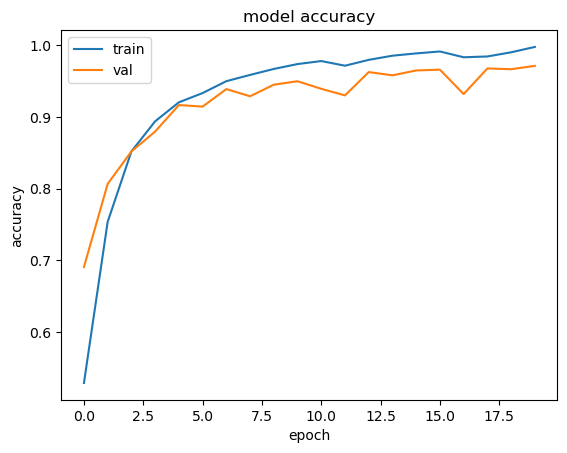

In [27]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

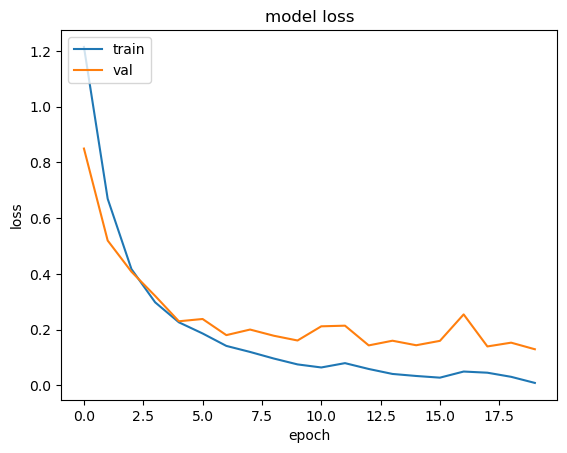

In [28]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

In [29]:
model.load_weights('best_model.h5')


294/294 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step


<Figure size 1200x500 with 0 Axes>

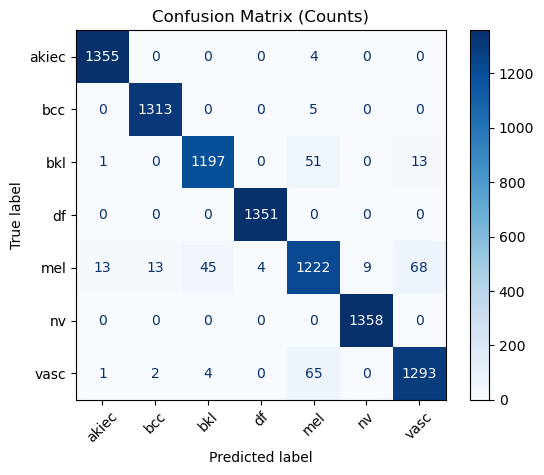

In [30]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np


y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = Y_test
# --- Define class names (example for HAM10000 dataset) ---
class_names = ['akiec', 'bcc', 'bkl', 'df', 'mel', 'nv', 'vasc']

# --- Confusion Matrix (Raw Counts) ---
cm = confusion_matrix(y_true_classes, y_pred_classes)
plt.figure(figsize=(12,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap='Blues', xticks_rotation=45, colorbar=True)
plt.title("Confusion Matrix (Counts)")
plt.show()

<Figure size 1200x500 with 0 Axes>

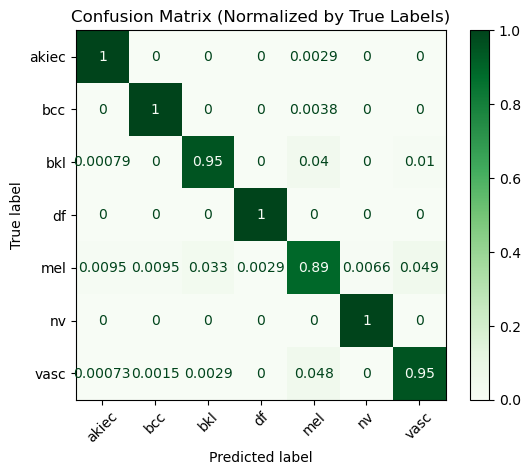

In [31]:
# --- Confusion Matrix (Normalized Percentages) ---
cm_normalized = confusion_matrix(y_true_classes, y_pred_classes, normalize='true')
plt.figure(figsize=(12,5))
disp_norm = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=class_names)
disp_norm.plot(cmap='Greens', xticks_rotation=45, colorbar=True)
plt.title("Confusion Matrix (Normalized by True Labels)")
plt.show()

# Model Testing

In [32]:
loss, acc = model.evaluate(X_test, Y_test, verbose=2)

294/294 - 2s - 5ms/step - accuracy: 0.9683 - loss: 0.1547


# Model Inference

Model expects images of size: 28x28x3
Found 20 image(s) in folder.


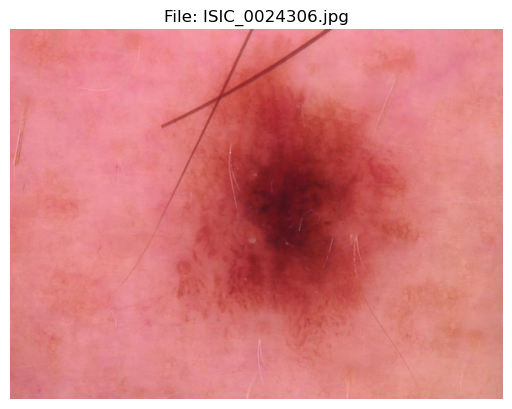

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
Image: ISIC_0024306.jpg
Predicted Class   : ('bcc', ' basal cell carcinoma')
Prediction Confidence: 0.93
--------------------------------------------------


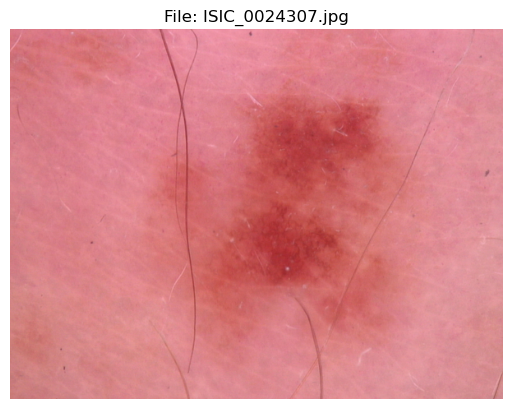

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
Image: ISIC_0024307.jpg
Predicted Class   : ('bcc', ' basal cell carcinoma')
Prediction Confidence: 0.91
--------------------------------------------------


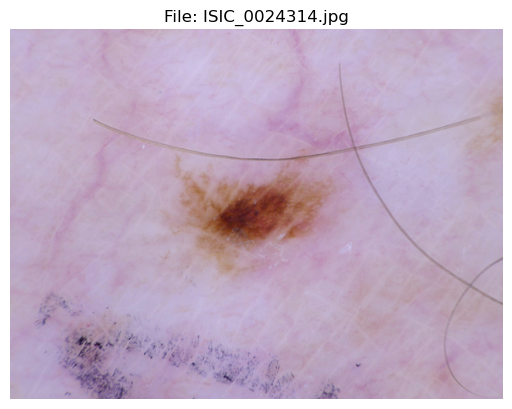

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step
Image: ISIC_0024314.jpg
Predicted Class   : ('bcc', ' basal cell carcinoma')
Prediction Confidence: 1.00
--------------------------------------------------


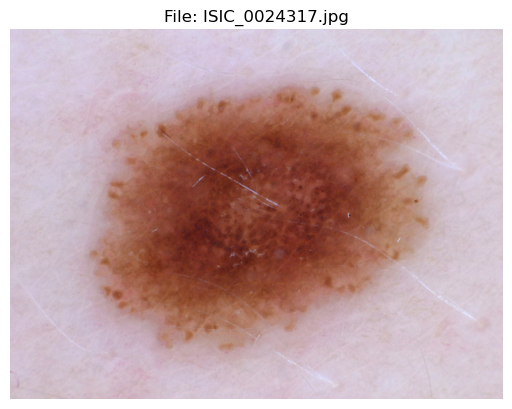

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Image: ISIC_0024317.jpg
Predicted Class   : ('bcc', ' basal cell carcinoma')
Prediction Confidence: 1.00
--------------------------------------------------


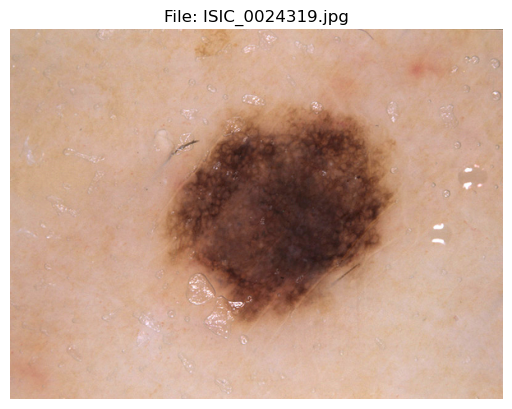

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Image: ISIC_0024319.jpg
Predicted Class   : ('bcc', ' basal cell carcinoma')
Prediction Confidence: 1.00
--------------------------------------------------


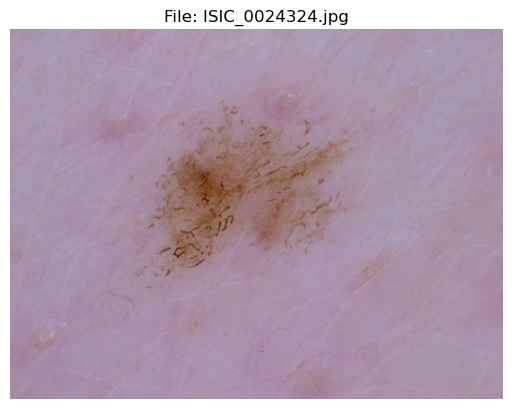

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
Image: ISIC_0024324.jpg
Predicted Class   : ('bcc', ' basal cell carcinoma')
Prediction Confidence: 1.00
--------------------------------------------------


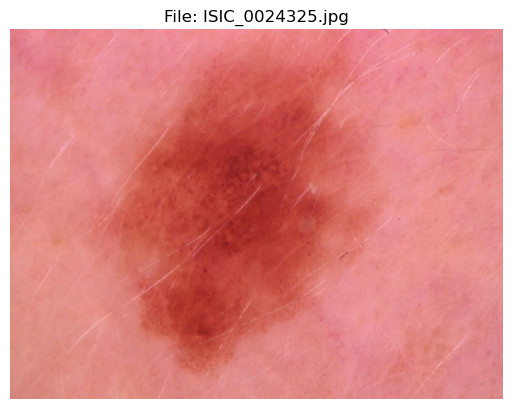

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Image: ISIC_0024325.jpg
Predicted Class   : ('bcc', ' basal cell carcinoma')
Prediction Confidence: 0.98
--------------------------------------------------


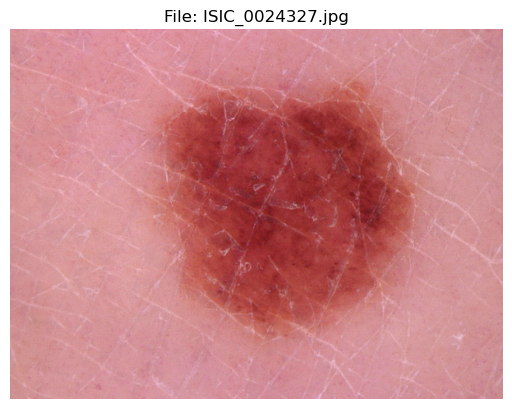

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Image: ISIC_0024327.jpg
Predicted Class   : ('bcc', ' basal cell carcinoma')
Prediction Confidence: 0.98
--------------------------------------------------


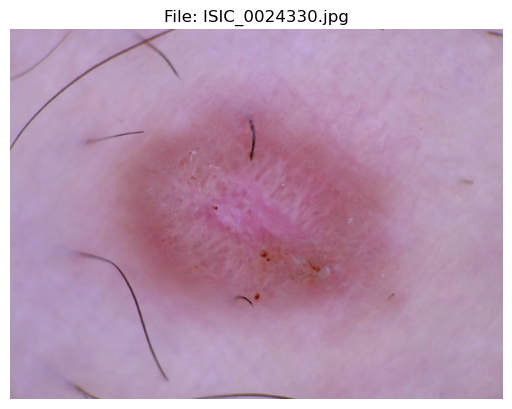

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Image: ISIC_0024330.jpg
Predicted Class   : ('bcc', ' basal cell carcinoma')
Prediction Confidence: 1.00
--------------------------------------------------


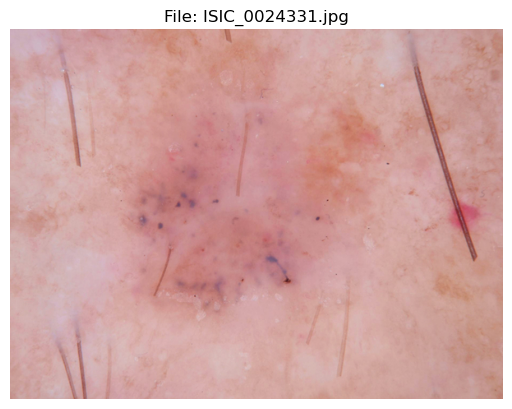

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step
Image: ISIC_0024331.jpg
Predicted Class   : ('bcc', ' basal cell carcinoma')
Prediction Confidence: 1.00
--------------------------------------------------


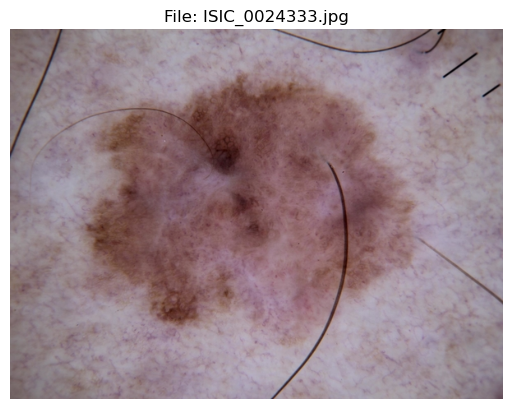

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step
Image: ISIC_0024333.jpg
Predicted Class   : ('bcc', ' basal cell carcinoma')
Prediction Confidence: 1.00
--------------------------------------------------


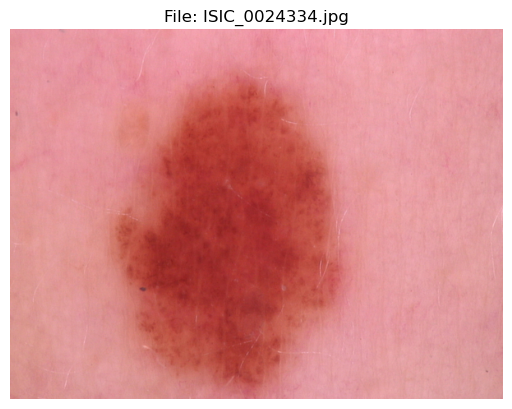

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 51ms/step
Image: ISIC_0024334.jpg
Predicted Class   : ('bcc', ' basal cell carcinoma')
Prediction Confidence: 0.93
--------------------------------------------------


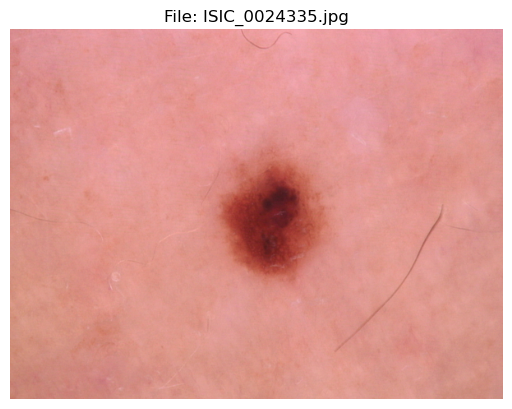

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Image: ISIC_0024335.jpg
Predicted Class   : ('bcc', ' basal cell carcinoma')
Prediction Confidence: 1.00
--------------------------------------------------


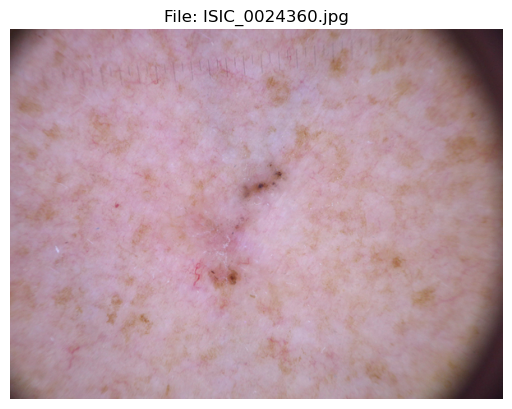

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Image: ISIC_0024360.jpg
Predicted Class   : ('bcc', ' basal cell carcinoma')
Prediction Confidence: 1.00
--------------------------------------------------


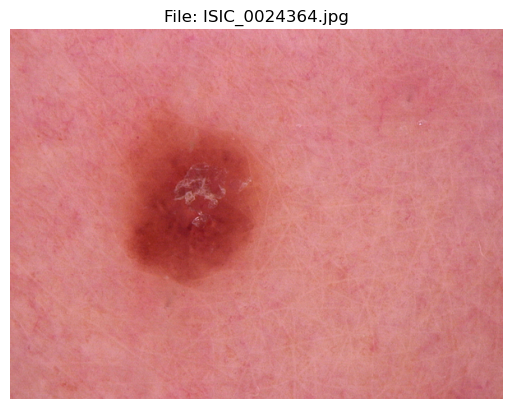

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Image: ISIC_0024364.jpg
Predicted Class   : ('bcc', ' basal cell carcinoma')
Prediction Confidence: 1.00
--------------------------------------------------


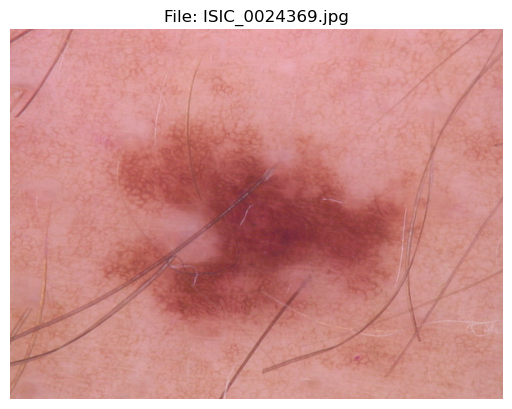

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Image: ISIC_0024369.jpg
Predicted Class   : ('bcc', ' basal cell carcinoma')
Prediction Confidence: 1.00
--------------------------------------------------


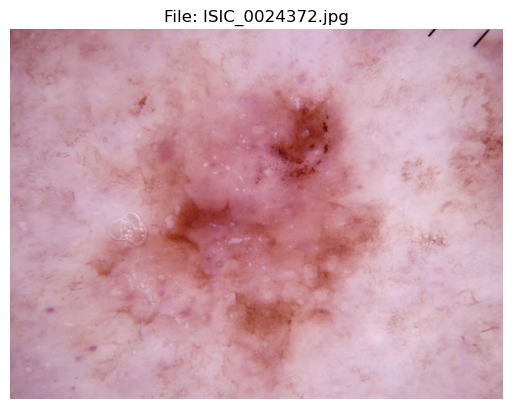

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Image: ISIC_0024372.jpg
Predicted Class   : ('bcc', ' basal cell carcinoma')
Prediction Confidence: 1.00
--------------------------------------------------


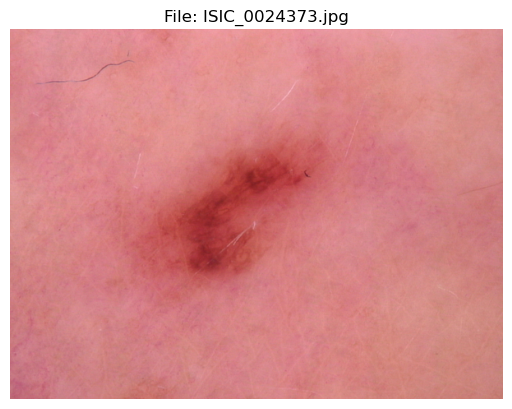

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Image: ISIC_0024373.jpg
Predicted Class   : ('bcc', ' basal cell carcinoma')
Prediction Confidence: 1.00
--------------------------------------------------


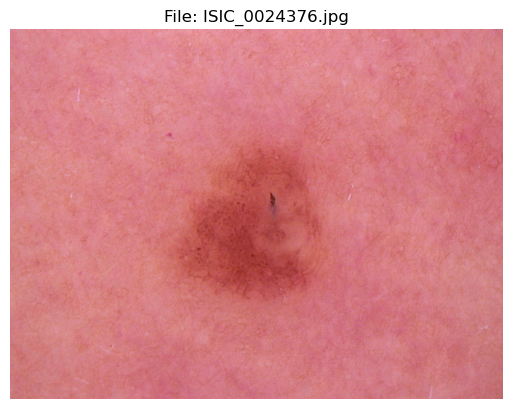

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step
Image: ISIC_0024376.jpg
Predicted Class   : ('bcc', ' basal cell carcinoma')
Prediction Confidence: 0.98
--------------------------------------------------


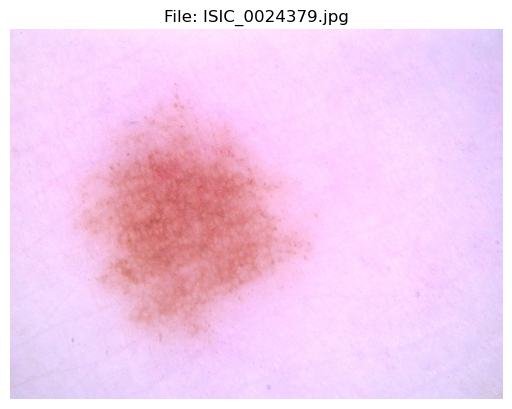

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 37ms/step
Image: ISIC_0024379.jpg
Predicted Class   : ('bcc', ' basal cell carcinoma')
Prediction Confidence: 1.00
--------------------------------------------------


In [46]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt


srcdir = r""

_, H, W, C = model.input_shape

print(f"Model expects images of size: {H}x{W}x{C}")

valid_exts = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

image_files = [
    f for f in os.listdir(srcdir)
    if f.lower().endswith(valid_exts)
]

print(f"Found {len(image_files)} image(s) in folder.")


for fname in image_files:
    img_path = os.path.join(srcdir, fname)

    # Read image
    img = cv2.imread(img_path)
    if img is None:
        print(f"Skipping (cannot read): {fname}")
        continue

    # Show original image
    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.title(f"File: {fname}")
    plt.axis('off')
    plt.show()

    # Resize to model input size
    img_resized = cv2.resize(img, (W, H))

    # Preprocess: reshape + scale
    img_input = img_resized.astype("float32") / 255.0  
    img_input = img_input.reshape(1, H, W, C)

    # Predict
    preds = model.predict(img_input)
    max_prob = float(np.max(preds[0]))
    class_ind = int(np.argmax(preds[0]))
    class_name = classes[class_ind]

    print(f"Image: {fname}")
    print(f"Predicted Class   : {class_name}")
    print(f"Prediction Confidence: {max_prob:.2f}")
    print("-" * 50)

In [47]:
import pickle

pickle.dump(model, open("cancer_detection_model.pkl", "wb"))
